<a href="https://colab.research.google.com/github/Kanhaiya219/networkx/blob/main/Exercise4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Number of nodes: 50
Number of edges: 100

Degree of each node:
Node 0: Degree 5
Node 1: Degree 5
Node 2: Degree 7
Node 3: Degree 6
Node 4: Degree 1
Node 5: Degree 3
Node 6: Degree 8
Node 7: Degree 3
Node 8: Degree 1
Node 9: Degree 3
Node 10: Degree 5
Node 11: Degree 3
Node 12: Degree 7
Node 13: Degree 4
Node 14: Degree 2
Node 15: Degree 6
Node 16: Degree 2
Node 17: Degree 5
Node 18: Degree 6
Node 19: Degree 4
Node 20: Degree 3
Node 21: Degree 6
Node 22: Degree 7
Node 23: Degree 1
Node 24: Degree 4
Node 25: Degree 3
Node 26: Degree 3
Node 27: Degree 6
Node 28: Degree 3
Node 29: Degree 2
Node 30: Degree 6
Node 31: Degree 3
Node 32: Degree 3
Node 33: Degree 2
Node 34: Degree 1
Node 35: Degree 5
Node 36: Degree 4
Node 37: Degree 5
Node 38: Degree 2
Node 39: Degree 5
Node 40: Degree 5
Node 41: Degree 4
Node 42: Degree 4
Node 43: Degree 5
Node 44: Degree 4
Node 45: Degree 3
Node 46: Degree 7
Node 47: Degree 3
Node 48: Degree 2
Node 49: Degree 3

Density of the graph: 0.08163265306122448
Is t

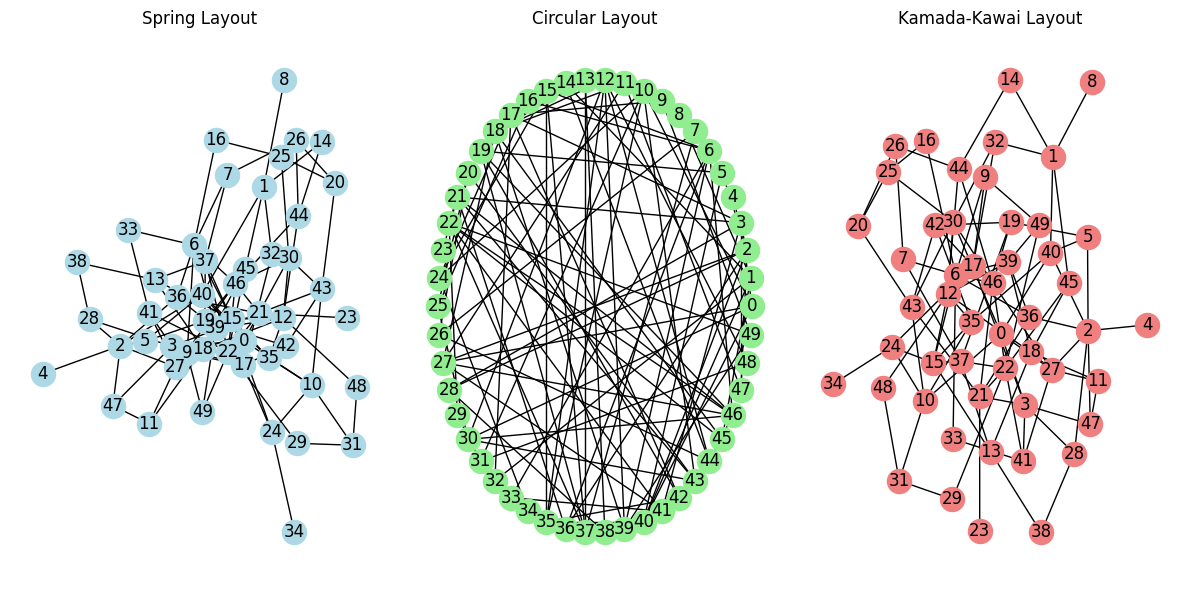

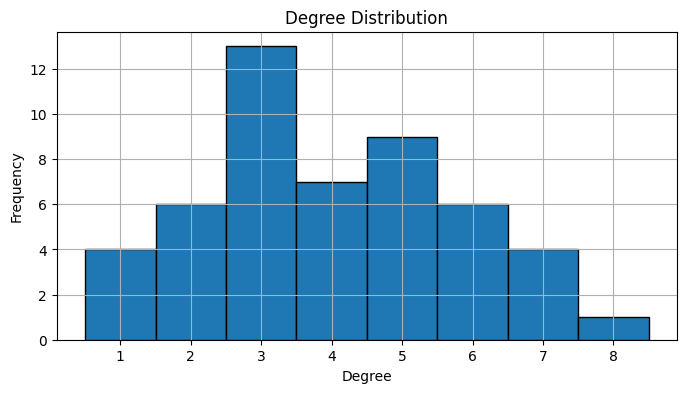

In [2]:
"""
Exercise 4

Create an undirected graph with **50 nodes and 100 random edges**, and show the following data about the graph:

* Number of nodes and edges
* Degree of each node
* Density, diameter, and average shortest path length (**if the graph is connected**)
* Check if the graph is connected
* Visualize the graph using `spring_layout`, `circular_layout`, and `kamada_kawai_layout`
* Plot the degree distribution for the above graph

"""

#importing networkx
import networkx as nx
import matplotlib.pyplot as plt
import random

G = nx.Graph()

#adding 50 random nodes
G.add_nodes_from(range(50))

#adding 100 random 100 edges
edges = set()
while len(edges) < 100:
    u = random.randint(0, 49)
    v = random.randint(0, 49)
    if u != v:
        edges.add(tuple(sorted((u, v))))
G.add_edges_from(edges)

# Print number of nodes and edges
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

# Degree of each node
degrees = dict(G.degree())
print("\nDegree of each node:")
for node, degree in degrees.items():
    print(f"Node {node}: Degree {degree}")

# Graph density
density = nx.density(G)
print("\nDensity of the graph:", density)

# Check if graph is connected
is_connected = nx.is_connected(G)
print("Is the graph connected?", is_connected)

# Compute diameter and average shortest path length for connected components
if is_connected:
    diameter = nx.diameter(G)
    avg_path_length = nx.average_shortest_path_length(G)
else:
    # For each connected component
    diameter = []
    avg_path_length = []
    for component in nx.connected_components(G):
        subgraph = G.subgraph(component)
        diameter.append(nx.diameter(subgraph))
        avg_path_length.append(nx.average_shortest_path_length(subgraph))
    print("Diameters of connected components:", diameter)
    print("Average shortest path lengths of components:", avg_path_length)

# Visualize using spring_layout
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
nx.draw(G, pos=nx.spring_layout(G), with_labels=True, node_color='lightblue')
plt.title("Spring Layout")


# Visualize using circular_layout
plt.subplot(1, 3, 2)
nx.draw(G, pos=nx.circular_layout(G), with_labels=True, node_color='lightgreen')
plt.title("Circular Layout")

# Visualize using kamada_kawai_layout
plt.subplot(1, 3, 3)
nx.draw(G, pos=nx.kamada_kawai_layout(G), with_labels=True, node_color='lightcoral')
plt.title("Kamada-Kawai Layout")

plt.tight_layout()
plt.show()

# Plot degree distribution
degree_values = list(degrees.values())
plt.figure(figsize=(8, 4))

plt.hist(
    degree_values,
    bins=range(min(degree_values), max(degree_values) + 2),
    align="left",
    edgecolor="black"
)

plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()